In [2]:
# ============================
# Confusion-matrix plotter
# ============================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_confusion_matrices(
    conf_mats,
    titles,
    class_names_list,
    cmap=None,
    values_type="fractions",   # "fractions" (0..1) from your screenshots OR "counts"
    annotate="auto",           # "auto" | "percent" | "count+percent"
    save_path="confusion_matrices.png"
):
    """
    Three confusion matrices side-by-side with ONE shared colorbar on a dedicated axis.
      - values_type="fractions": entries are already row-normalized (0..1).
      - values_type="counts": rows will be normalized to compute percentages.
      - annotate:
          * "auto" -> if fractions, show only percent; if counts, show count+percent
          * "percent" -> only percentages
          * "count+percent" -> show both (only meaningful when values_type="counts")
      - Only the leftmost matrix shows the 'Actual' y-axis label; middle/right hide y tick labels.
      - Supply per-matrix class names in class_names_list.
    """
    assert len(conf_mats) == 3 and len(titles) == 3 and len(class_names_list) == 3
    assert values_type in {"fractions", "counts"}

    if cmap is None:
        # light blue sequential
        cmap = LinearSegmentedColormap.from_list(
            "light_blues", ["#e8f3ff", "#95c9ff", "#2a8df0"], N=256
        )

    # 3 matrices + a slim colorbar axis (prevents overlap)
    fig, axes = plt.subplots(
        1, 4, figsize=(36, 12),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.045]}
    )
    plt.subplots_adjust(wspace=0.10)

    axs, cax = axes[:3], axes[3]
    im = None

    # Decide annotation mode
    if annotate == "auto":
        annot_mode = "percent" if values_type == "fractions" else "count+percent"
    else:
        annot_mode = annotate

    for i, (ax, cm, title, cls_names) in enumerate(zip(axs, conf_mats, titles, class_names_list)):
        cm = np.array(cm, dtype=float)

        if values_type == "fractions":
            cm_pct = cm  # already 0..1 per row
            row_sums = cm.sum(axis=1, keepdims=True)  # only for showing counts, if ever provided
        else:
            row_sums = cm.sum(axis=1, keepdims=True)
            with np.errstate(divide="ignore", invalid="ignore"):
                cm_pct = np.divide(cm, row_sums, where=row_sums != 0)

        # identical 0..1 scale across all three
        im = ax.imshow(cm_pct, cmap=cmap, vmin=0.0, vmax=1.0, aspect="auto")

        # Titles/labels (match your bold, large style)
        ax.set_title(title, fontsize=42, fontweight="bold", pad=20)
        ax.set_xlabel("Predicted", fontsize=36, fontweight="bold", labelpad=10)
        if i == 0:
            ax.set_ylabel("Actual", fontsize=36, fontweight="bold", labelpad=10)

        # Ticks & labels
        ax.set_xticks(range(cm.shape[1]))
        ax.set_yticks(range(cm.shape[0]))
        ax.set_xticklabels(cls_names, rotation=60, ha="right", fontsize=30, fontweight="bold")
        if i == 0:
            ax.set_yticklabels(cls_names, fontsize=30, fontweight="bold")
        else:
            ax.set_yticklabels([])

        # Thick outer border
        for s in ax.spines.values():
            s.set_linewidth(5.0)

        # Annotations
        for r in range(cm.shape[0]):
            for c in range(cm.shape[1]):
                pct = cm_pct[r, c] * 100
                if annot_mode == "percent":
                    txt = f"{pct:.2f}"
                elif annot_mode == "count+percent" and values_type == "counts":
                    count = int(cm[r, c])
                    txt = f"{count}\n{pct:.1f}%"
                else:  # fallback to percent
                    txt = f"{pct:.1f}%"
                ax.text(c, r, txt, ha="center", va="center",
                        fontsize=22, fontweight="bold", color="black")

    # One shared colorbar on dedicated axis
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Row fraction", fontsize=28, fontweight="bold")
    cbar.ax.tick_params(labelsize=26)
    for lbl in cbar.ax.get_yticklabels():
        lbl.set_fontweight("bold")
    cbar.outline.set_linewidth(3.0)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

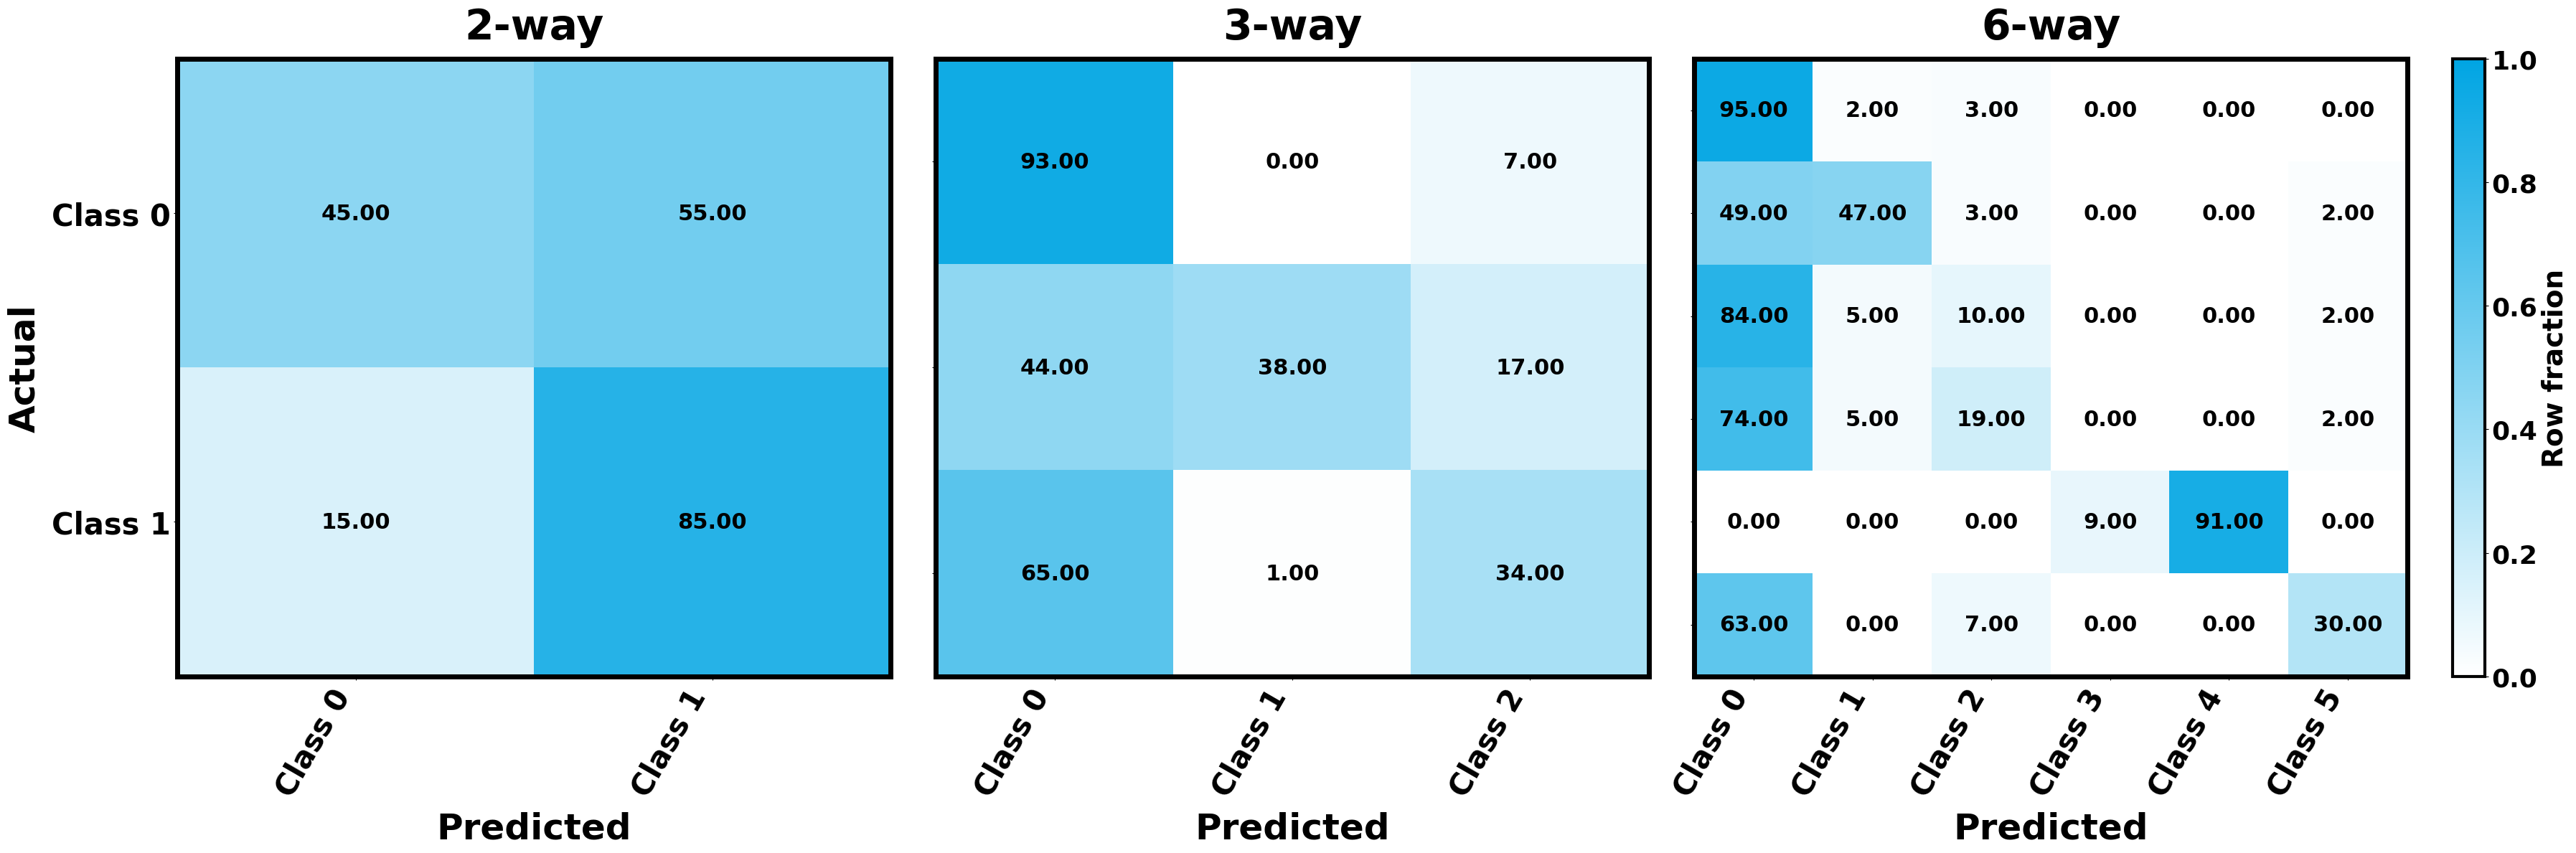

In [5]:
# ============================
# Hard-coded confusion matrices (fractions)
# ============================
# 2-way (rows sum to 1)
cm2_frac = np.array([
    [0.45, 0.55],
    [0.15, 0.85],
], dtype=float)

# 3-way
cm3_frac = np.array([
    [0.93, 0.00, 0.07],
    [0.44, 0.38, 0.17],
    [0.65, 0.01, 0.34],
], dtype=float)

# 6-way
cm6_frac = np.array([
    [0.95, 0.02, 0.03, 0.00, 0.00, 0.00],
    [0.49, 0.47, 0.03, 0.00, 0.00, 0.02],
    [0.84, 0.05, 0.10, 0.00, 0.00, 0.02],
    [0.74, 0.05, 0.19, 0.00, 0.00, 0.02],
    [0.00, 0.00, 0.00, 0.09, 0.91, 0.00],
    [0.63, 0.00, 0.07, 0.00, 0.00, 0.30],
], dtype=float)

conf_mats = [cm2_frac, cm3_frac, cm6_frac]
titles = ["2-way", "3-way", "6-way"]
class_names_list = [
    ["Class 0","Class 1"],
    ["Class 0","Class 1","Class 2"],
    ["Class 0","Class 1","Class 2","Class 3","Class 4","Class 5"],   # digits only for 6-way
]

# Your light sequential cmap (white -> teal)
conf_cmap = LinearSegmentedColormap.from_list("my_cmap", ["#ffffff", "#00a5e3"], N=256)

plot_confusion_matrices(
    conf_mats=conf_mats,
    titles=titles,
    class_names_list=class_names_list,
    cmap=conf_cmap,
    values_type="fractions",     # <-- using the screenshot fractions
    annotate="percent",          # show only percentages inside cells
    save_path="confusion_matrices_image_only.png"
)

In [67]:
def plot_metric_bars(
    model_labels,
    metrics_dict,
    colors,
    save_path="metrics_comparison.png"
):
    """
    Grouped bar chart comparing metrics across models.
    - model_labels: ["2-way", "3-way", "6-way"]
    - metrics_dict: {"Accuracy":[..], "Precision":[..], "Recall":[..], "F1":[..]}
    - colors: tuple/list of 3 hex codes for the models
    """
    metric_names = list(metrics_dict.keys())
    vals = [metrics_dict[m] for m in metric_names]

    x = np.arange(len(metric_names))
    n_models = len(model_labels)
    width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(24, 7))
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for j in range(n_models):
        offsets = x - 0.4 + width/2 + j * width
        y = [vals[i][j] for i in range(len(metric_names))]
        bars = ax.bar(
            offsets, y, width=width,
            color=colors[j % len(colors)],
            edgecolor="#444", linewidth=4,
            label=model_labels[j]
        )
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=25, color="#2b2b2b", rotation=90, fontweight="bold", )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=40)
    ax.set_ylabel("Score", fontsize=50)
    ax.set_ylim(0, max(1.0, max(max(v) for v in vals) + 0.1))
    ax.legend(loc="upper right", fontsize=24, frameon=True)
    ax.spines["top"].set_linewidth(4.0)
    ax.spines["bottom"].set_linewidth(4.0)
    ax.spines["left"].set_linewidth(4.0)
    ax.spines["right"].set_linewidth(4.0)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [6]:
# ============================
# Metrics from screenshots
# ============================
model_labels = ["2-way", "3-way", "6-way"]
metrics = {
    "Accuracy":  [0.6707, 0.6647, 0.6173],
    "Precision": [0.6810, 0.7047, 0.5766],  # macro
    "Recall":    [0.6492, 0.5477, 0.4543],  # macro
    "F1":        [0.6449, 0.5745, 0.4705],  # macro
}

# choose your colors
bar_colors = ["#d9d2e9", "#feffbf", "#d0e4ee"]  # pastel purple, yellow, blue

# Plot metrics
plot_metric_bars(
    model_labels,
    metrics,
    colors=bar_colors,
    save_path="metrics_comparison_image_only.png"
)

NameError: name 'plot_metric_bars' is not defined